In [8]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.dataset import load_dataset
from src.model import create_model
from src.train import train_head_model, fine_tune_model
from src.evaluate import load_trained_model, evaluate_model
from src.predictions import predict_image

In [7]:
import importlib
import src.predictions

importlib.reload(src.predictions)

<module 'src.predictions' from 'e:\\ML-Projects\\Cats-vs-Dogs\\notebooks\\..\\src\\predictions.py'>

In [2]:
train_dataset, validation_dataset= load_dataset()

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


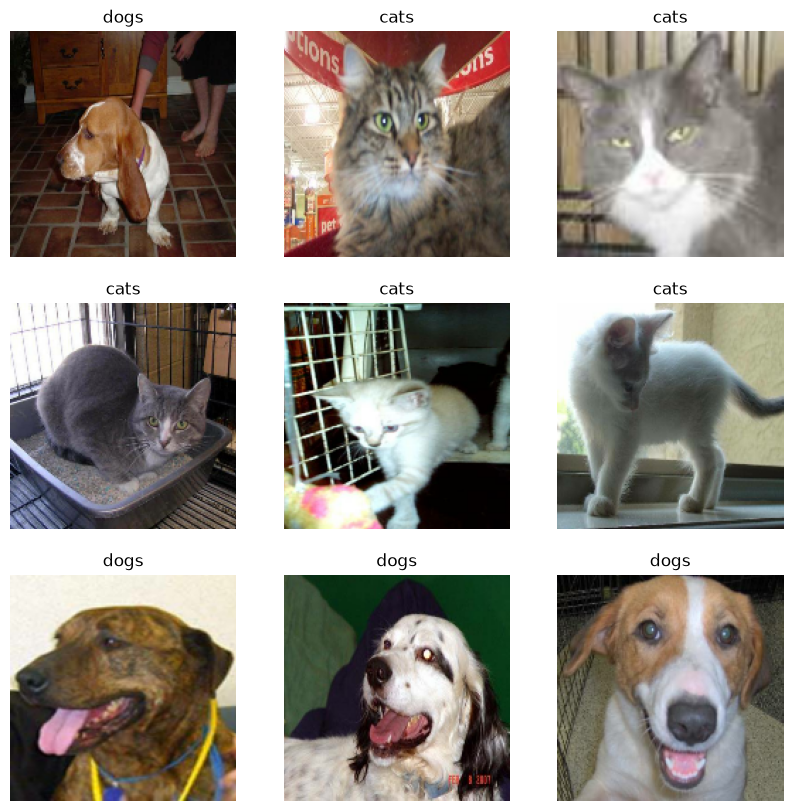

In [3]:
class_names=train_dataset.class_names

plt.figure(figsize=(10,10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [4]:
model=create_model()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [5]:
model, history=train_head_model()

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Epoch 1/5


e:\ML-Projects\Cats-vs-Dogs\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.8560 - loss: 0.3233
Epoch 1: val_loss improved from None to 0.10574, saving model to ../models/head_training.keras

Epoch 1: finished saving model to ../models/head_training.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 289ms/step - accuracy: 0.8560 - loss: 0.3233 - val_accuracy: 0.9720 - val_loss: 0.1057
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9275 - loss: 0.1797
Epoch 2: val_loss improved from 0.10574 to 0.07639, saving model to ../models/head_training.keras

Epoch 2: finished saving model to ../models/head_training.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 276ms/step - accuracy: 0.9275 - loss: 0.1797 - val_accuracy: 0.9750 - val_loss: 0.0764
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9385 - loss: 0.1524
Epoch 3: val_loss improved from 0.07639 to 0.06668, saving model to ../models/head_training.keras

Epoch 3: finished saving model to ../models/head_training.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 27

In [6]:
model.layers

[<InputLayer name=input_layer_4, built=True>,
 <Sequential name=sequential, built=True>,
 <Functional name=mobilenetv2_1.00_160, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d_1, built=True>,
 <Dropout name=dropout_1, built=True>,
 <Dense name=dense_1, built=True>]

In [7]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,829 (8.63 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2,564 (10.02 KB)

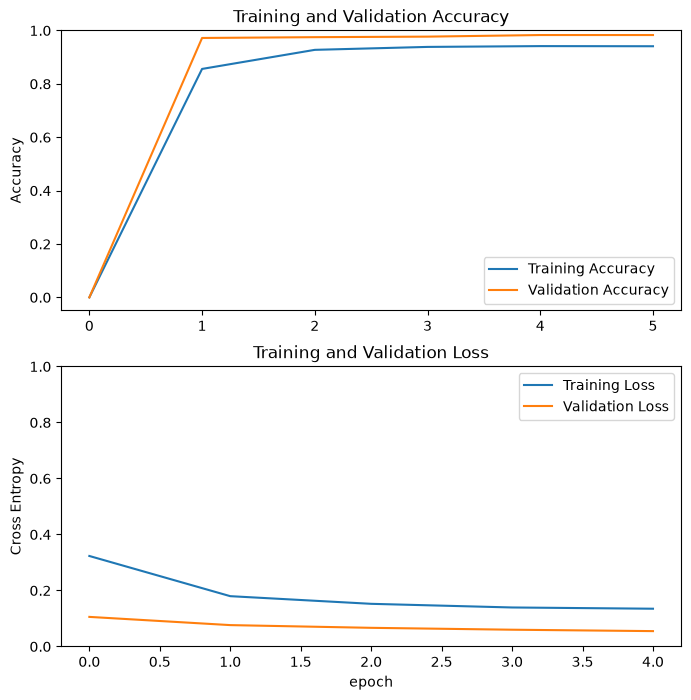

In [8]:
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [9]:
final_model, final_history=fine_tune_model(history.epoch[-1])

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Epoch 5/10


e:\ML-Projects\Cats-vs-Dogs\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9195 - loss: 0.1916
Epoch 5: val_loss improved from None to 0.03630, saving model to ../models/final_training.keras

Epoch 5: finished saving model to ../models/final_training.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 27s 339ms/step - accuracy: 0.9195 - loss: 0.1916 - val_accuracy: 0.9850 - val_loss: 0.0363
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.9455 - loss: 0.1338
Epoch 6: val_loss did not improve from 0.03630
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 322ms/step - accuracy: 0.9455 - loss: 0.1338 - val_accuracy: 0.9840 - val_loss: 0.0393
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9635 - loss: 0.0948
Epoch 7: val_loss did not improve from 0.03630
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 320ms/step - accuracy: 0.9635 - loss: 0.0948 - val_accuracy: 0.9810 - val_loss: 0.0525
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.9710 - loss: 0.0786
Epoch 8: val_loss did not improve from 0.03630
63/63 ━━━━

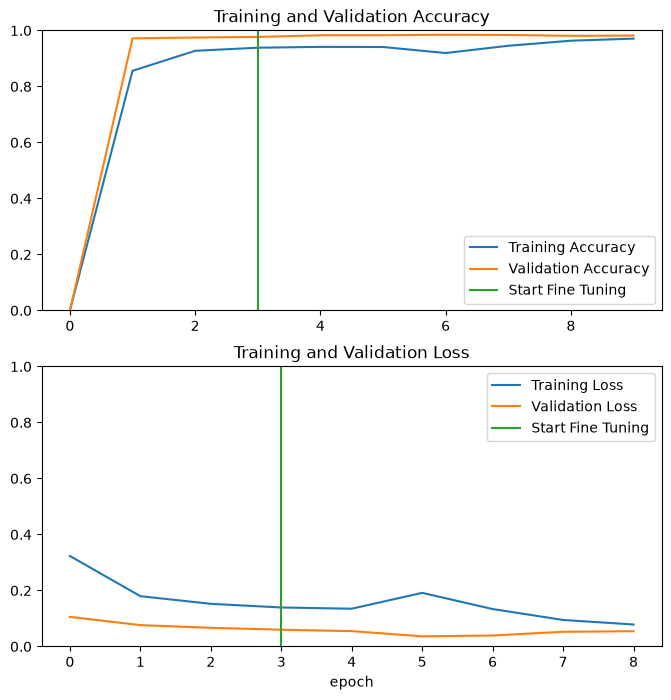

In [10]:
acc += final_history.history['accuracy']
val_acc += final_history.history['val_accuracy']

loss += final_history.history['loss']
val_loss += final_history.history['val_loss']
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1])
plt.plot([history.epoch[-1]-1,history.epoch[-1]-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([history.epoch[-1]-1,history.epoch[-1]-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [11]:
final_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,511,621 (21.03 MB)

 Trainable params: 1,626,177 (6.20 MB)

 Non-trainable params: 633,088 (2.42 MB)

 Optimizer params: 3,252,356 (12.41 MB)

In [ ]:
prediction=predict_image(model_path="E:/ML-Projects/Cats-vs-Dogs/models/final_training.keras", img_path="E:/ML-Projects/Cats-vs-Dogs/datasets/validation/dogs/dog.2008.jpg")

prediction

ValueError: File not found: filepath=models/final_training.keras. Please ensure the file is an accessible `.keras` zip file.